In [9]:
!pip install sentence-transformers matplotlib seaborn scikit-learn

In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [11]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler took an important wicket for his team.",
    "The captain changed the field during the powerplay.",
    "The team celebrated after winning the cricket tournament.",

    # Cooking
    "She added salt and spices to the soup.",
    "The chef baked a fresh chocolate cake in the oven.",
    "Vegetables and rice were cooked for dinner.",

    # Cybersecurity
    "Strong passwords help keep online accounts safe.",
    "The company installed a firewall to protect the network.",
    "Phishing emails can steal personal information from users."
]

In [14]:
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (10, 384)


In [15]:
similarity_matrix = cosine_similarity(embeddings)

df_similarity = pd.DataFrame(similarity_matrix, index=sentences, columns=sentences)
df_similarity

,The batsman scored a century in the final match.,The bowler took an important wicket for his team.,The captain changed the field during the powerplay.,The team celebrated after winning the cricket tournament.,She added salt and spices to the soup.,The chef baked a fresh chocolate cake in the oven.,Vegetables and rice were cooked for dinner.,Strong passwords help keep online accounts safe.,The company installed a firewall to protect the network.,Phishing emails can steal personal information from users.
The batsman scored a century in the final match.,1.000000,0.614092,0.249109,0.547351,-0.042878,0.087513,0.117603,-0.038402,0.029998,-0.068414
The bowler took an important wicket for his team.,0.614092,1.000000,0.303648,0.543405,0.100037,0.110076,0.159883,0.014274,0.120459,-0.052493
The captain changed the field during the powerplay.,0.249109,0.303648,1.000000,0.247762,0.047501,-0.051937,-0.021602,-0.001558,0.132514,0.003653
The team celebrated after winning the cricket tournament.,0.547351,0.543405,0.247762,1.000000,0.050231,0.087161,0.196382,-0.048042,0.109087,-0.040595
She added salt and spices to the soup.,-0.042878,0.100037,0.047501,0.050231,1.000000,0.119226,0.377417,-0.008965,0.113265,-0.027481
The chef baked a fresh chocolate cake in the oven.,0.087513,0.110076,-0.051937,0.087161,0.119226,1.000000,0.166000,-0.085126,0.067399,0.063614
Vegetables and rice were cooked for dinner.,0.117603,0.159883,-0.021602,0.196382,0.377417,0.166000,1.000000,-0.115964,0.027838,-0.052571
Strong passwords help keep online accounts safe.,-0.038402,0.014274,-0.001558,-0.048042,-0.008965,-0.085126,-0.115964,1.000000,0.188873,0.438675
The company installed a firewall to protect the network.,0.029998,0.120459,0.132514,0.109087,0.113265,0.067399,0.027838,0.188873,1.000000,0.141724
Phishing emails can steal personal information from users.,-0.068414,-0.052493,0.003653,-0.040595,-0.027481,0.063614,-0.052571,0.438675,0.141724,1.000000


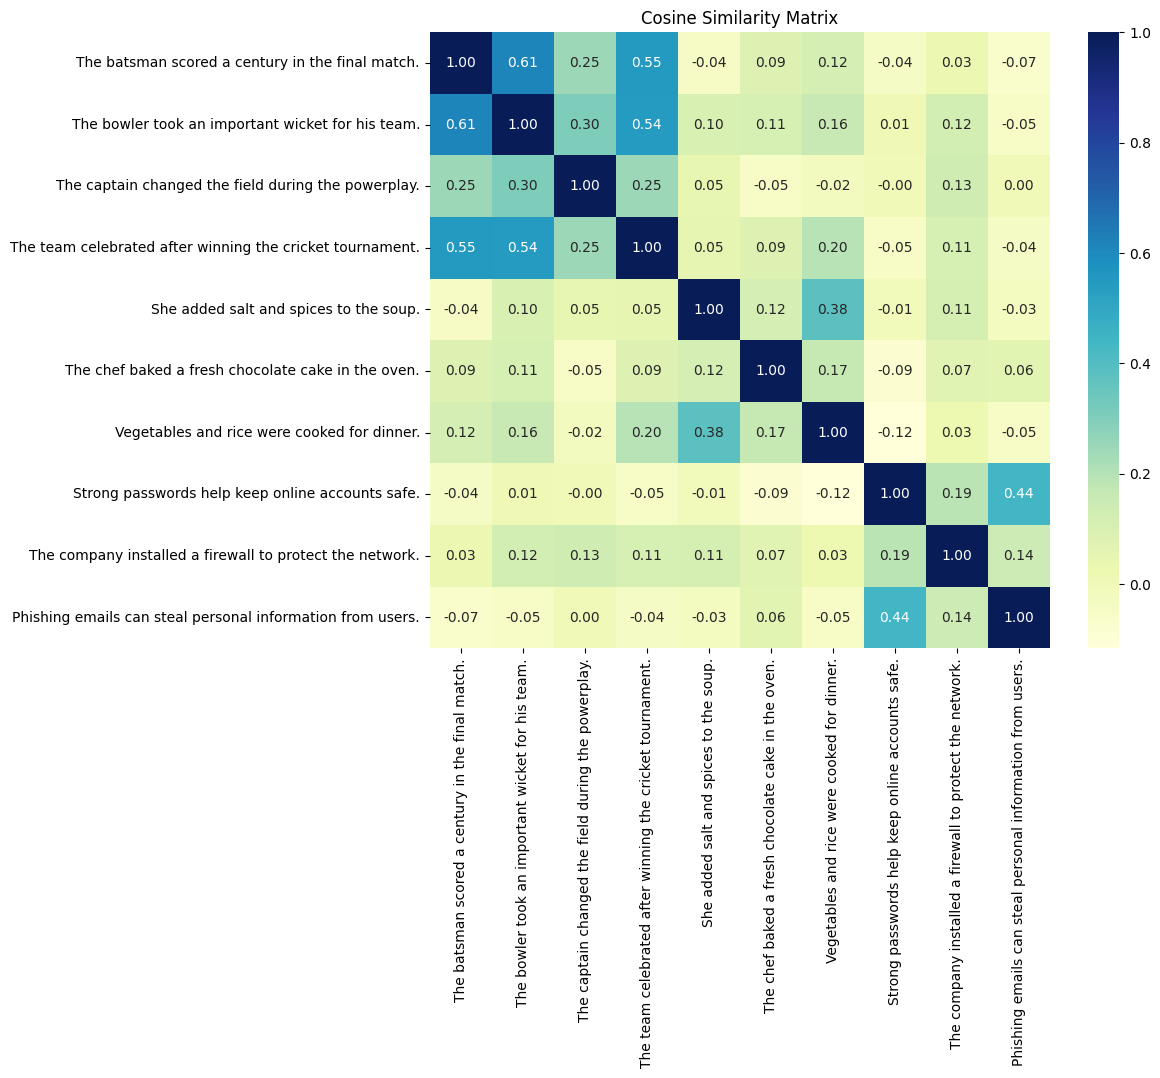

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_similarity, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cosine Similarity Matrix")
plt.show()

In [17]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])
query_similarity = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, query_similarity))
results = sorted(results, key=lambda x: x[1], reverse=True)

print("Query sentence:", query)
print("\nTop 2 most similar sentences:")
for sentence, score in results[:2]:
    print(f"{sentence} --> Similarity score: {score:.4f}")

Query sentence: The bowler took three wickets in one over

Top 2 most similar sentences:
The bowler took an important wicket for his team. --> Similarity score: 0.8026
The batsman scored a century in the final match. --> Similarity score: 0.5679
